In [ ]:
'''
PROGETTO DI IMAGES SEGMENTATION SUL DATASET CRACK500 PER IL RILEVAMENTO DELLE CREPE

NOTEBOOK IN COLAB PER ADDESTRARE IL MODELLO U-NET
'''

In [1]:
'''
Creazione della classe per caricare il dataset da kaggle e preparare i dati con Keras
'''

import os
import glob
import tensorflow as tf
import keras

class SegmentationDataLoader:

    def __init__(self, base_path, batch_size=16, img_size=(256, 256)):
        self.base_path = base_path
        self.batch_size = batch_size
        self.img_size = img_size

    def _load_and_preprocess(self, img_path, mask_path):
        """Funzione interna per leggere e normalizzare immagini e maschere."""
        # 1. Carica e decodifica l'immagine originale (RGB)
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        # metodo di resize bilinear (default): ogni nuovo pixel è la media ponderata dei 4 pixel più vicini
        img = tf.image.resize(img, self.img_size)
        # Normalizza i pixel nel range [0.0, 1.0]
        img = tf.cast(img, tf.float32) / 255.0

        # 2. Carica e decodifica la maschera (Scala di grigi)
        mask = tf.io.read_file(mask_path)

        mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
        # utilizzo di nearest neighbour per il resize (copia del pixel più vicino), forzando così due valori possibili (sfondo o crepa)
        mask = tf.image.resize(mask, self.img_size, method="nearest")
        # Normalizza la maschera (0 = sfondo, 1 = crepa)
        mask = tf.cast(mask, tf.float32) / 255.0

        return img, mask

    def get_dataset(self, split="train", shuffle=True):
        """
        Genera un tf.data.Dataset pronto per l'uso.
        split può essere: 'train', 'val', 'test'
        """
        # Trova le cartelle corrette all'interno del path di kagglehub
        images_dir = os.path.join(self.base_path, split, "images")
        masks_dir = os.path.join(self.base_path, split, "masks")

        # Recupera i percorsi di tutti i file ordinandoli per farli combaciare perfettamente
        # Usiamo glob per catturare sia estensioni maiuscole che minuscole (es. .jpg, .JPG, .png)
        img_paths = sorted(glob.glob(os.path.join(images_dir, "*.*")))
        mask_paths = sorted(glob.glob(os.path.join(masks_dir, "*.*")))

        if len(img_paths) == 0:
            raise FileNotFoundError(f"Nessuna immagine trovata nel percorso: {images_dir}. "
                                    "Verifica la struttura delle cartelle scaricate.")

        # Crea la pipeline nativa ad alte prestazioni di TensorFlow
        # ogni elemento della lista è la coppia: (percorso_immagine_X, percorso_maschera_X)
        dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

        # le immagini vengono mescolate per evitare possibili correlazioni tra immagini e posizione
        if shuffle:
            dataset = dataset.shuffle(buffer_size=len(img_paths), reshuffle_each_iteration=True)

        # Applica il pre-processing in parallelo sfruttando la CPU multi-core, AUTOTUNE decide in automatico la modalità migliore
        dataset = dataset.map(self._load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

        # Raggruppa in batch da 16 immagini e prepara in anticipo i dati in memoria per far lavorare in parallelo CPU e GPU
        dataset = dataset.batch(self.batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

        print(f"Dataset '{split}' creato con successo! Elementi totali: {len(img_paths)} ({len(img_paths)//self.batch_size} batch).")
        return dataset

In [2]:
import kagglehub

# 1. Scarica il dataset tramite kagglehub
path = kagglehub.dataset_download("vangiap/crack500-dataset")
print("Path to dataset files:", path)

# 2. Inizializza il DataLoader generico
# Possibilità di impostare la dimensione dell'immagine e la dimensione del batch
data_loader = SegmentationDataLoader(base_path=path, batch_size=16, img_size=(256, 256))

# 3. Estrazione dei 3 dataset pronti per Keras
train_ds = data_loader.get_dataset(split="train", shuffle=True)
val_ds = data_loader.get_dataset(split="val", shuffle=False)
test_ds = data_loader.get_dataset(split="test", shuffle=False)


100%|██████████| 369M/369M [00:06<00:00, 61.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vangiap/crack500-dataset/versions/1
Dataset 'train' creato con successo! Elementi totali: 1896 (118 batch).
Dataset 'val' creato con successo! Elementi totali: 348 (21 batch).
Dataset 'test' creato con successo! Elementi totali: 1119 (69 batch).


--- VERIFICA DIMENSIONI ---
Forma del batch di immagini: (16, 256, 256, 3)
Forma del batch di maschere: (16, 256, 256, 1)

--- VERIFICA VALORI PIXEL ---
Valore Min/Max Immagine: 0.0 / 1.0
Valore Min/Max Maschera: 0.0 / 1.0


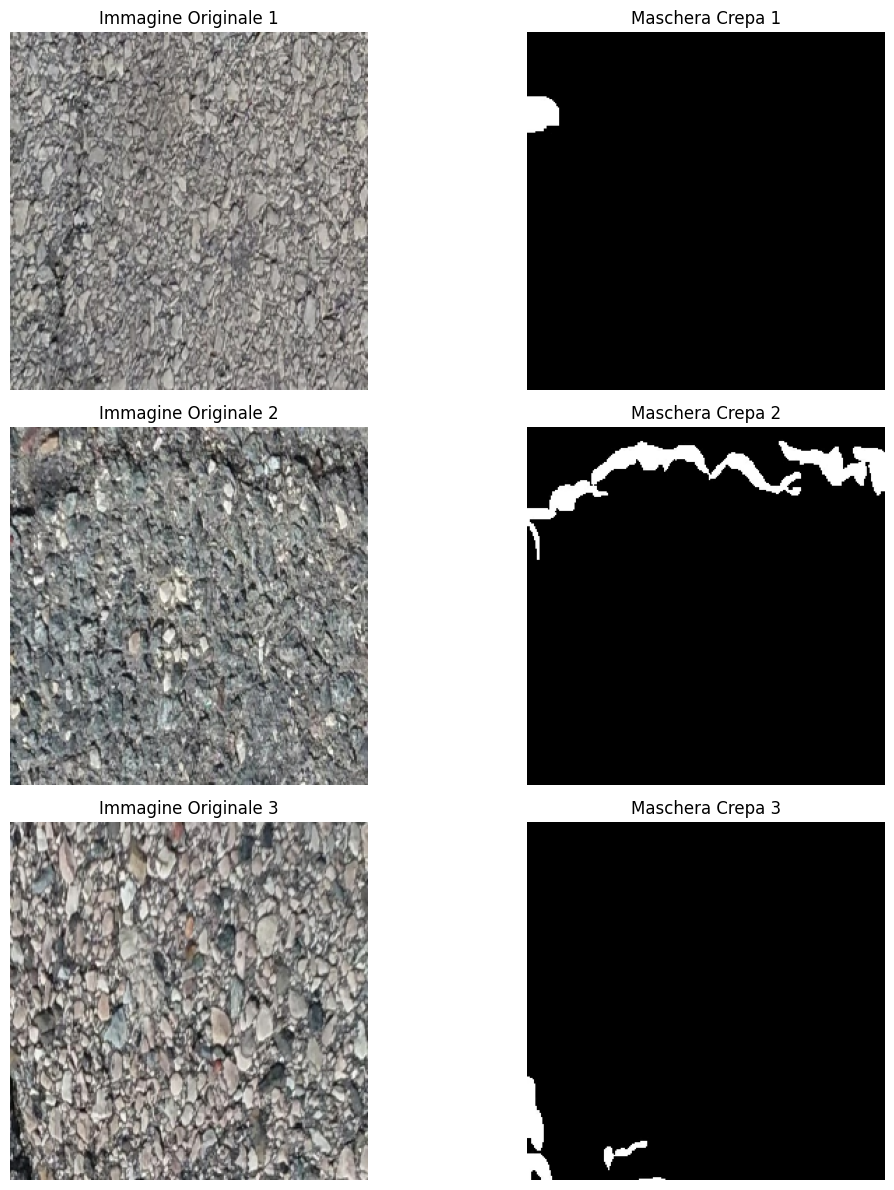

In [3]:
''' Verifica del corretto caricamento dei dati '''

import matplotlib.pyplot as plt
import numpy as np

# 1. Estraiamo un singolo batch (un pacchetto di immagini) dal train_ds
# .take(1) dice a TensorFlow di prendere solo il primo batch e fermarsi
for images_batch, masks_batch in train_ds.take(1):

    # Convertiamo i tensori in array NumPy per poterli stampare con matplotlib
    images = images_batch.numpy()
    masks = masks_batch.numpy()

    print("--- VERIFICA DIMENSIONI ---")
    print(f"Forma del batch di immagini: {images.shape}") # Dovrebbe essere (16, 256, 256, 3) se il batch_size è 16
    print(f"Forma del batch di maschere: {masks.shape}")  # Dovrebbe essere (16, 256, 256, 1)

    print("\n--- VERIFICA VALORI PIXEL ---")
    print(f"Valore Min/Max Immagine: {images.min()} / {images.max()}") # Dovrebbe essere 0.0 / 1.0 grazie alla divisione per 255
    print(f"Valore Min/Max Maschera: {masks.min()} / {masks.max()}") # Dovrebbe essere 0.0 (sfondo) e 1.0 (crepa)

    # 2. Disegniamo le prime 3 immagini del batch con le loro relative maschere
    num_esempi = 3
    plt.figure(figsize=(12, 4 * num_esempi))

    for i in range(num_esempi):
        # Subplot per l'immagine originale
        plt.subplot(num_esempi, 2, 2 * i + 1)
        plt.imshow(images[i])
        plt.title(f"Immagine Originale {i+1}")
        plt.axis("off")

        # Subplot per la maschera della crepa
        plt.subplot(num_esempi, 2, 2 * i + 2)
        # Usiamo .squeeze() per rimuovere il canale da 1 (da 256x256x1 a 256x256) richiesto da imshow per il b/n
        plt.imshow(masks[i].squeeze(), cmap="gray")
        plt.title(f"Maschera Crepa {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
''' Creazione della classe per costruire la rete U-Net classica per la segmentazione delle immagini'''

import keras
from keras import layers

class UNetStandard:

    def __init__(self, input_shape=(256, 256, 3), num_classes=1):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def _double_conv_block(self, x, n_filters):
        '''
        Blocco base ripetuto: due convoluzioni consecutive da 3x3,
        ciascuna seguita da Batch Normalization e attivazione ReLU.
        '''
        # Prima Convoluzione
        x = layers.Conv2D(n_filters, kernel_size=3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        # Seconda Convoluzione
        x = layers.Conv2D(n_filters, kernel_size=3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        return x

    def build_model(self):
        '''Costruisce e restituisce il modello Keras completo.'''
        inputs = layers.Input(shape=self.input_shape)

        # ==========================================
        # 1. ENCODER (Fase di contrazione)
        # ==========================================
        # Blocco 1: In 256x256x3 -> Out 256x256x64 (Dimezza a 128x128)
        c1 = self._double_conv_block(inputs, 64)
        p1 = layers.MaxPooling2D(pool_size=2)(c1)

        # Blocco 2: In 128x128x64 -> Out 128x128x128 (Dimezza a 64x64)
        c2 = self._double_conv_block(p1, 128)
        p2 = layers.MaxPooling2D(pool_size=2)(c2)

        # Blocco 3: In 64x64x128 -> Out 64x64x256 (Dimezza a 32x32)
        c3 = self._double_conv_block(p2, 256)
        p3 = layers.MaxPooling2D(pool_size=2)(c3)

        # Blocco 4: In 32x32x256 -> Out 32x32x512 (Dimezza a 16x16)
        c4 = self._double_conv_block(p3, 512)
        p4 = layers.MaxPooling2D(pool_size=2)(c4)

        # ==========================================
        # 2. BOTTLENECK (Il punto più profondo)
        # ==========================================
        # In 16x16x512 -> Out 16x16x1024
        bottleneck = self._double_conv_block(p4, 1024)

        # ==========================================
        # 3. DECODER (Fase di espansione)
        # ==========================================
        # Blocco 1: Ingrandisce il bottleneck (a 32x32) e lo concatena con c4
        u1 = layers.Conv2DTranspose(512, kernel_size=2, strides=2, padding="same")(bottleneck)
        u1 = layers.Concatenate()([u1, c4]) # Skip Connection
        c5 = self._double_conv_block(u1, 512)

        # Blocco 2: Ingrandisce (a 64x64) e lo concatena con c3
        u2 = layers.Conv2DTranspose(256, kernel_size=2, strides=2, padding="same")(c5)
        u2 = layers.Concatenate()([u2, c3]) # Skip Connection
        c6 = self._double_conv_block(u2, 256)

        # Blocco 3: Ingrandisce (a 128x128) e lo concatena con c2
        u3 = layers.Conv2DTranspose(128, kernel_size=2, strides=2, padding="same")(c6)
        u3 = layers.Concatenate()([u3, c2]) # Skip Connection
        c7 = self._double_conv_block(u3, 128)

        # Blocco 4: Ingrandisce (a 256x256) e lo concatena con c1
        u4 = layers.Conv2DTranspose(64, kernel_size=2, strides=2, padding="same")(c7)
        u4 = layers.Concatenate()([u4, c1]) # Skip Connection
        c8 = self._double_conv_block(u4, 64)

        # ==========================================
        # 4. TESTA DI OUTPUT (Segmentation Head)
        # ==========================================
        # 1 filtro finale con attivazione Sigmoid:
        # restituisce una probabilità da 0.0 a 1.0 per ogni singolo pixel.
        outputs = layers.Conv2D(self.num_classes, kernel_size=1, activation="sigmoid")(c8)

        # modello Keras definitivo
        model = keras.Model(inputs=inputs, outputs=outputs, name="U-Net_Standard_Crack500")
        return model

In [5]:
# Istanziamo la classe (impostando l'input a 256x256 a 3 canali)
unet_builder = UNetStandard(input_shape=(256, 256, 3), num_classes=1)

# Generiamo il modello
model = unet_builder.build_model()

# tabella riassuntiva di tutti gli strati
model.summary()

Model: "U-Net_Standard_Crack500"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,728 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,049,409 (118.44 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [6]:
''' Classe in cui vengono definite la funzione di perdita (dice_bce_loss) e le metriche di valutazione (dice_coefficient)'''

import tensorflow as tf
import keras

class SegmentationMetrics:
    @staticmethod
    def dice_bce_loss(y_true, y_pred):
        smooth = 1e-6
        # Calcolo della Binary Crossentropy standard di Keras
        bce = keras.losses.binary_crossentropy(y_true, y_pred)

        # Appiattimento dei tensori usando tf.reshape
        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])

        # Calcolo del Dice Coefficient con le ops di Keras 3
        intersection = keras.ops.sum(y_true_f * y_pred_f)
        dice_score = (2. * intersection + smooth) / (keras.ops.sum(y_true_f) + keras.ops.sum(y_pred_f) + smooth)

        return bce + (1.0 - dice_score)

    @staticmethod
    def dice_coefficient(y_true, y_pred):
        smooth = 1e-6

        y_pred_bin = tf.cast(tf.greater(y_pred, 0.5), dtype="float32")

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred_bin, [-1])

        intersection = keras.ops.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (keras.ops.sum(y_true_f) + keras.ops.sum(y_pred_f) + smooth)

In [7]:
''' Fase di addestramento del modello con l'utilizzo del optimizer Adam, learning rate = 1e-4, dice_bce_loss'''

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=SegmentationMetrics.dice_bce_loss,
    metrics=[SegmentationMetrics.dice_coefficient, "accuracy"]
)

# Avvio del .fit() senza errori
history = model.fit(train_ds, validation_data=val_ds, epochs=25)

Epoch 1/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9200 - dice_coefficient: 0.5584 - loss: 1.0004 - val_accuracy: 0.9184 - val_dice_coefficient: 1.3919e-11 - val_loss: 1.2458
Epoch 2/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 93s 780ms/step - accuracy: 0.9553 - dice_coefficient: 0.6726 - loss: 0.7132 - val_accuracy: 0.9184 - val_dice_coefficient: 1.3919e-11 - val_loss: 1.1877
Epoch 3/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 94s 793ms/step - accuracy: 0.9585 - dice_coefficient: 0.6955 - loss: 0.6238 - val_accuracy: 0.9236 - val_dice_coefficient: 0.1493 - val_loss: 1.0579
Epoch 4/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 97s 817ms/step - accuracy: 0.9602 - dice_coefficient: 0.7060 - loss: 0.5684 - val_accuracy: 0.9602 - val_dice_coefficient: 0.7630 - val_loss: 0.4889
Epoch 5/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 98s 820ms/step - accuracy: 0.9615 - dice_coefficient: 0.7156 - loss: 0.5274 - val_accuracy: 0.9650 - val_dice_coefficient: 0.8125 - val_loss: 0.3897
Epoch 6/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 97s 818ms

In [8]:
# Viene montato Drive su Google Colab

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Viene stamapto il riassunto della U-Net se è ancora in memoria
model.summary()

Model: "U-Net_Standard_Crack500"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,728 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 93,124,677 (355.24 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 11,776 (46.00 KB)

 Optimizer params: 62,075,268 (236.80 MB)

In [10]:
''' Salvataggio del modello su Google Drive '''

import os

# Creiamo la cartella nel tuo Drive
os.makedirs('/content/drive/MyDrive/Progetto_Crepe', exist_ok=True)

# Salviamo il modello
model.save('/content/drive/MyDrive/Progetto_Crepe/best_unet_model.keras')
print("Salvataggio completato! Controlla il tuo Google Drive.")

Salvataggio completato! Controlla il tuo Google Drive.
